First 5 rows of data:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


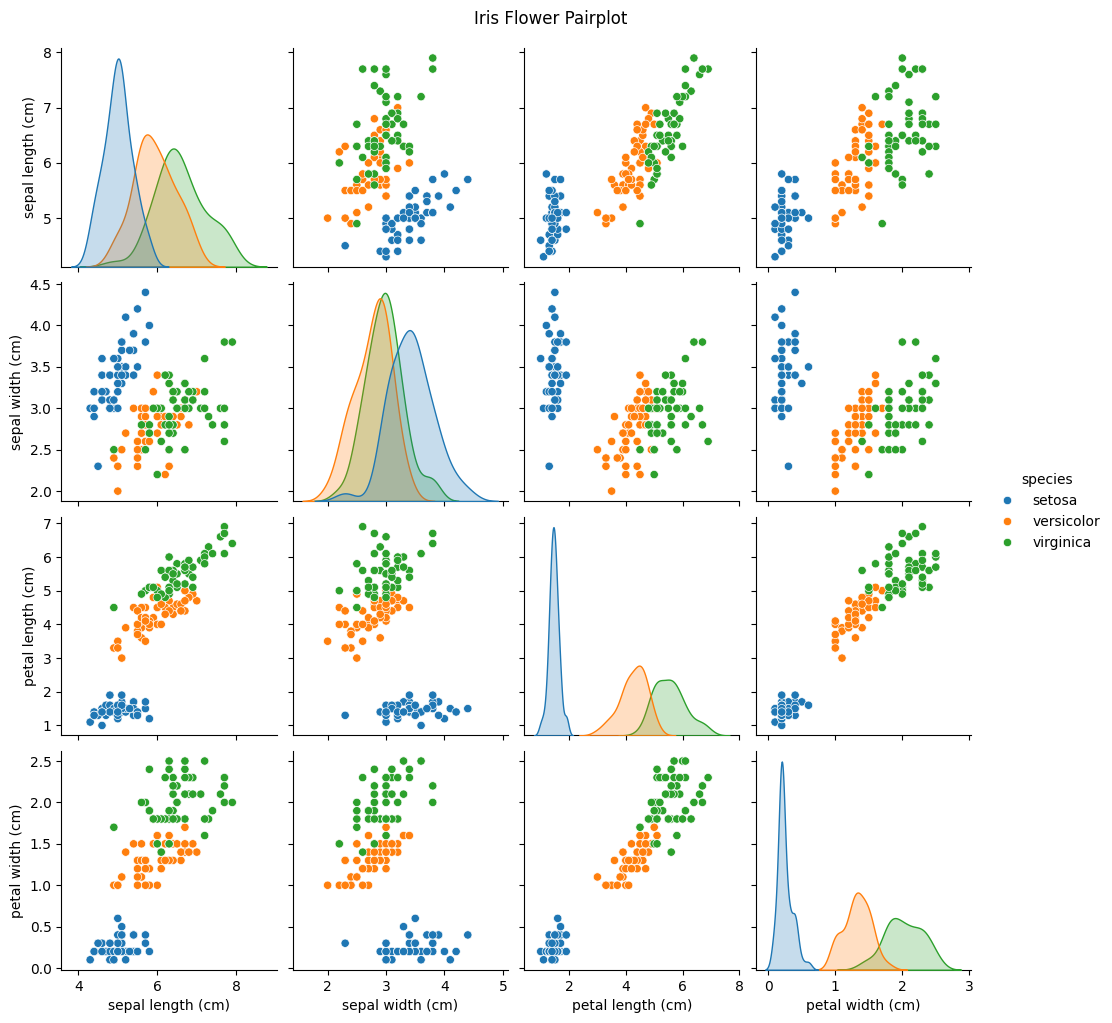


Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [1]:
# 1. Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Load the Dataset (Built into scikit-learn)
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target numbers to actual flower names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 3. Exploratory Data Analysis (EDA)
print("First 5 rows of data:")
print(df.head())

# Visualize the data
sns.pairplot(df, hue='species')
plt.suptitle("Iris Flower Pairplot", y=1.02)
plt.show()

# 4. Preprocessing (Split data into features and target)
X = df.drop('species', axis=1) # Features (measurements)
y = df['species']              # Target (flower name)

# Split into training (80%) and testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 6. Evaluate the Model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, predictions))
